In [45]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation=None)

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)



In [46]:
import numpy as np
import pandas as pd

def compute_scalar_ability(theta_df, a_df, b_series, item_ids, v_unit=None, adjust_difficulty=True, return_v_unit=False):
	"""
	Compute a bbq-specific ability score from MIRT factors, discriminations, and difficulties.
	
	Args:
		theta_df (pd.DataFrame): Factor scores per test taker (rows = test takers, cols = factors).
		a_df (pd.DataFrame): Discrimination parameters (rows = items, cols = factors).
		b_series (pd.Series): Difficulty parameters (indexed same as a_df rows).
		item_ids (list): List of item IDs (subset of a_df rows) that are bbq items.
		adjust_difficulty (bool): Whether to weight discriminations by difficulty.
	
	Returns:
		pd.Series: bbq ability scores for each test taker.
	"""
	if v_unit is None:
		# 1. Extract discrimination vectors for bbq items
		A_bbq = a_df.loc[item_ids].copy()
		b_bbq = b_series.loc[item_ids]

		# 2. Optionally adjust by difficulty
		if adjust_difficulty:
			weights = 1 / (1 + np.abs(b_bbq.values))
			A_bbq = A_bbq.multiply(weights, axis=0)

		# 3. Compute bbq direction vector in factor space
		v_unit = A_bbq.mean(axis=0).values  # vector of length = num_factors
		v_unit = v_unit / np.linalg.norm(v_unit)  # normalize for stability
		print("Mean unit vector: ", v_unit)
		if return_v_unit:
			return v_unit

	else: 
		print("Used pre-computed direction vector.", v_unit)

	# 4. Project each test taker's theta onto v_unit
	theta_matrix = theta_df.values  # shape (n_test_takers, n_factors)
	bbq_scores = theta_matrix.dot(v_unit)

	return pd.Series(bbq_scores, index=theta_df.index, name="ability")


In [47]:
conv_dataset = ['bbq', 'gsm']


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

pd.DataFrame(scenario_questions, columns=['question']).to_pickle('../result/bbq_scenario_questions.pkl')

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

In [48]:
import numpy as np
import pandas as pd

def orthogonalize_vector(vector_to_purify, reference_vector):
    """
    Purifies a vector by removing its projection onto a reference vector.
    This is a single step of the Gram-Schmidt process.

    Args:
        vector_to_purify (np.ndarray): The vector you want to purify (e.g., v_bbq).
        reference_vector (np.ndarray): The vector representing the component to remove (e.g., v_div).

    Returns:
        np.ndarray: The purified, orthogonal vector, normalized to unit length.
    """
    # Ensure vectors are normalized to unit length to start
    vector_to_purify = vector_to_purify / np.linalg.norm(vector_to_purify)
    reference_vector = reference_vector / np.linalg.norm(reference_vector)

    # 1. Calculate the projection of vector_to_purify onto reference_vector
    dot_product = np.dot(vector_to_purify, reference_vector)
    projection = dot_product * reference_vector
    
    # 2. Subtract the projection to get the orthogonal component
    purified_vector = vector_to_purify - projection
    
    # 3. Normalize the final vector to have a length of 1
    purified_vector_normalized = purified_vector / np.linalg.norm(purified_vector)
    
    return purified_vector_normalized

# Verification with Eigenvectors

In [49]:
import pandas as pd
import numpy as np

def get_reference_composite_eigenvector(a_df: pd.DataFrame) -> np.ndarray:
    """
    Calculates the eigenvector for the reference composite from a matrix of 
    multidimensional discrimination parameters.

    This vector corresponds to the largest eigenvalue of the a'a matrix and 
    represents the direction of the dominant unidimensional scale in the 
    multidimensional space.

    Args:
        a_df: A pandas DataFrame with shape (n_items, n_dimensions) 
              containing the 'a' parameters.

    Returns:
        A NumPy array representing the eigenvector of the reference composite.
    """
    # Convert the DataFrame to a NumPy array for matrix operations
    a_matrix = a_df.to_numpy()
    
    # Calculate the a-transpose-a matrix (a'a)
    a_t_a = a_matrix.T @ a_matrix
    
    # Calculate the eigenvalues and eigenvectors of the a'a matrix
    eigenvalues, eigenvectors = np.linalg.eig(a_t_a)
    
    # Find the index of the largest eigenvalue
    max_eigenvalue_index = np.argmax(eigenvalues)
    
    # Select the corresponding eigenvector
    reference_composite_vector = eigenvectors[:, max_eigenvalue_index]
    
    return reference_composite_vector

In [50]:
conv_dataset = ['bbq', 'gsm']

models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()
inverse_mask = ~items_mask
inverse_questions = resmat.columns[inverse_mask].get_level_values('input.text').to_list()
 
v_unit = compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, return_v_unit=True)
v_bbq_unit = get_reference_composite_eigenvector(a_df.loc[scenario_questions])

# --- Main Execution ---

v_bbq_initial = v_bbq_unit
v_div_reference = v_unit

# --- Run the Orthogonalization ---
v_bbq_pure = orthogonalize_vector(v_bbq_initial, v_div_reference)

print("Purified 'bbq' Vector (v_bbq_pure):")
print(np.round(v_bbq_pure, 4))

# --- Verification ---
# The dot product of the purified vector and the reference vector should be nearly zero.
final_correlation = np.dot(v_bbq_pure, v_div_reference / np.linalg.norm(v_div_reference))
print(f"\nCorrelation after Orthogonalization (Dot Product): {final_correlation:.4f}")

if np.isclose(final_correlation, 0):
    print("Verification successful: The new bbq vector is orthogonal to the divergent vector.")
else:
    print("Verification failed.")

Mean unit vector:  [ 0.1744052   0.10057444 -0.18807302  0.14714333 -0.12119867 -0.05218033
  0.10791499  0.3329943  -0.25573274 -0.28377432 -0.03563029  0.19608806
 -0.33211437 -0.51385707  0.06059998  0.08487863  0.1611557   0.25581488
  0.3165704 ]
Purified 'bbq' Vector (v_bbq_pure):
[ 0.1995  0.2589  0.2913  0.0822  0.3287  0.2048 -0.041  -0.2058  0.4236
  0.0979  0.0051  0.3001 -0.3384 -0.0516 -0.2046  0.3608 -0.1352  0.0068
  0.1443]

Correlation after Orthogonalization (Dot Product): 0.0000
Verification failed.


In [51]:
bbq_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_bbq_pure)
div_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, v_unit)
conv_benchmark_mean = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)

div_bbq_corr = bbq_scores_pure.corr(div_scores_pure, method='spearman')
print('div_corr', div_bbq_corr)

conv_bbq_corr = bbq_scores_pure.corr(conv_benchmark_mean, method='spearman')
print('conv_corr', conv_bbq_corr)

Used pre-computed direction vector. [ 0.19949925  0.25891286  0.29134825  0.08216283  0.32874113  0.20479338
 -0.04098136 -0.20576835  0.42357472  0.09793021  0.00507652  0.3001112
 -0.33841312 -0.05164242 -0.20463406  0.36078712 -0.13523231  0.00678893
  0.14433795]
Used pre-computed direction vector. [ 0.1744052   0.10057444 -0.18807302  0.14714333 -0.12119867 -0.05218033
  0.10791499  0.3329943  -0.25573274 -0.28377432 -0.03563029  0.19608806
 -0.33211437 -0.51385707  0.06059998  0.08487863  0.1611557   0.25581488
  0.3165704 ]
div_corr -0.07731078614899001
conv_corr -0.9131141397204338


In [52]:
conv_dataset = ['wikifacts']


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()
inverse_mask = ~items_mask
inverse_questions = resmat.columns[inverse_mask].get_level_values('input.text').to_list()
 
v_unit = compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, return_v_unit=True)
v_wikifacts_unit = get_reference_composite_eigenvector(a_df.loc[scenario_questions])


# --- Main Execution ---

v_wikifacts_initial = v_wikifacts_unit
v_div_reference = v_unit

# --- Run the Orthogonalization ---
v_wikifacts_pure = orthogonalize_vector(v_wikifacts_initial, v_div_reference)

print("Purified Vector:")
print(np.round(v_wikifacts_pure, 4))

# --- Verification ---
# The dot product of the purified vector and the reference vector should be nearly zero.
final_correlation = np.dot(v_wikifacts_pure, v_div_reference / np.linalg.norm(v_div_reference))
print(f"\nCorrelation after Orthogonalization (Dot Product): {final_correlation:.4f}")

if np.isclose(final_correlation, 0, atol=1e-6):
    print("Verification successful: The new vector is orthogonal to the divergent vector.")
else:
    print("Verification failed.")

Mean unit vector:  [ 0.17145725  0.08870739 -0.20358695  0.14671828 -0.13429108 -0.05920028
  0.10769302  0.34324414 -0.28028986 -0.28678212 -0.03357641  0.18363827
 -0.312891   -0.5107769   0.07399787  0.06050678  0.16560888  0.2546213
  0.30489472]
Purified Vector:
[ 0.9852 -0.0154  0.0354 -0.0255  0.0234  0.0103 -0.0187 -0.0597  0.0488
  0.0499  0.0058 -0.032   0.0545  0.0889 -0.0129 -0.0105 -0.0288 -0.0443
 -0.0531]

Correlation after Orthogonalization (Dot Product): -0.0000
Verification successful: The new vector is orthogonal to the divergent vector.


In [53]:
conv_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_wikifacts_pure)
div_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, v_unit)
conv_benchmark_mean = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)

div_wikifacts_corr = conv_scores_pure.corr(div_scores_pure, method='spearman')
print('div_corr', div_wikifacts_corr)

conv_wikifacts_corr = conv_scores_pure.corr(conv_benchmark_mean, method='spearman')
print('conv_corr', conv_wikifacts_corr)

Used pre-computed direction vector. [ 0.9851915  -0.01543814  0.03543114 -0.02553403  0.02337127  0.01030289
 -0.01874229 -0.05973629  0.04878008  0.04990996  0.00584345 -0.03195938
  0.05445381  0.08889276 -0.01287818 -0.01053026 -0.02882165 -0.04431287
 -0.05306217]
Used pre-computed direction vector. [ 0.17145725  0.08870739 -0.20358695  0.14671828 -0.13429108 -0.05920028
  0.10769302  0.34324414 -0.28028986 -0.28678212 -0.03357641  0.18363827
 -0.312891   -0.5107769   0.07399787  0.06050678  0.16560888  0.2546213
  0.30489472]
div_corr -0.04604340776828304
conv_corr nan


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_6822/2956096361.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


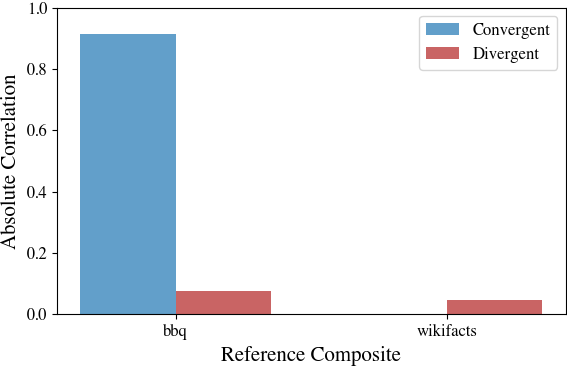

In [54]:
sys.path.append('..') 
import style
import matplotlib.pyplot as plt
plt.rcParams.update(style.rcparams)
import numpy as np

pcs = [f'PC{i+1}' for i in range(2)]
conv_corrs = np.absolute([conv_bbq_corr, conv_wikifacts_corr])
div_corrs = np.absolute([div_bbq_corr, div_wikifacts_corr])

# Create the two-bar histogram
x = np.arange(len(pcs))  # PC positions
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, conv_corrs, width, label='Convergent', color='C0', alpha=0.7)
bars2 = ax.bar(x + width/2, div_corrs, width, label='Divergent', color='firebrick', alpha=0.7)

# Customize the plot
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('Reference Composite')
ax.set_xticks(x)
ax.set_xticklabels(['bbq', 'wikifacts'])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(f'../result/selective_scale_correlations.pdf')
plt.show()

In [55]:
score_bbq_pure = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_bbq_pure)
score_wikifacts_pure = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_wikifacts_pure)

score_bbq_pure.corr(score_wikifacts_pure, method='spearman')

Used pre-computed direction vector. [ 0.19949925  0.25891286  0.29134825  0.08216283  0.32874113  0.20479338
 -0.04098136 -0.20576835  0.42357472  0.09793021  0.00507652  0.3001112
 -0.33841312 -0.05164242 -0.20463406  0.36078712 -0.13523231  0.00678893
  0.14433795]
Used pre-computed direction vector. [ 0.9851915  -0.01543814  0.03543114 -0.02553403  0.02337127  0.01030289
 -0.01874229 -0.05973629  0.04878008  0.04990996  0.00584345 -0.03195938
  0.05445381  0.08889276 -0.01287818 -0.01053026 -0.02882165 -0.04431287
 -0.05306217]


np.float64(0.7123882888316246)

In [56]:
mean_bbq_pure = score_bbq_pure.mean()
mean_wikifacts_pure = score_wikifacts_pure.mean()

v1 = v_bbq_pure
v2 = v_wikifacts_pure
mean_v1 = mean_bbq_pure
mean_v2 = mean_wikifacts_pure

a = 0.5

p = theta @ (a*v1 + (1-a)*v2) - (a * mean_v1 + (1-a) * mean_v2)

In [ ]:
# Get mean scores and find common indices (models that have non-NaN values for both)
common_indices = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['legalbench', 'med_qa'])]].dropna().index.to_list()
print(len(common_indices))

models_to_highlight = models_to_name.keys()
print(len(list(i for i in common_indices if i in list(models_to_highlight))))
# count each company in common_indices
company_counts = {}
for model in common_indices:
    company = model.split('/')[0]
    if company not in company_counts:
        company_counts[company] = 0
    company_counts[company] += 1
print(company_counts)

89
9
{'allenai': 1, 'cohere': 4, 'AlephAlpha': 3, 'mistralai': 7, 'ai21': 5, 'meta': 12, 'microsoft': 3, 'google': 11, 'databricks': 1, '01-ai': 3, 'openai': 9, 'tiiuae': 2, 'qwen': 8, 'anthropic': 10, 'snowflake': 1, 'writer': 3, 'deepseek-ai': 2, 'amazon': 3, 'upstage': 1}


In [68]:
list(models_to_highlight)

['deepseek-ai/deepseek-v3',
 'meta/llama-3.1-70b-instruct-turbo',
 'meta/llama-3.1-405b-instruct-turbo',
 'anthropic/claude-3-haiku-20240307',
 'openai/gpt-4o-2024-08-06',
 'google/gemini-1.5-pro-002',
 'qwen/qwen2-72b-instruct',
 'cohere/command-r',
 'databricks/dbrx-instruct']

In [ ]:
scenarios = [
    'lsat_qa', 'truthful_qa', 'synthetic_reasoning', 'babi_qa', 'wikifact',
    'bbq', 'thai_exam', 'dyck_language_np=3', 'legal_support',
    'legalbench', 'civil_comments', 'raft', 'air_bench_2024', 'math',
    'med_qa', 'gsm', 'boolq', 'mmlu', 'entity_matching',
    'entity_data_imputation', 'commonsense', 'imdb'
]

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_6822/1469327178.py:303: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


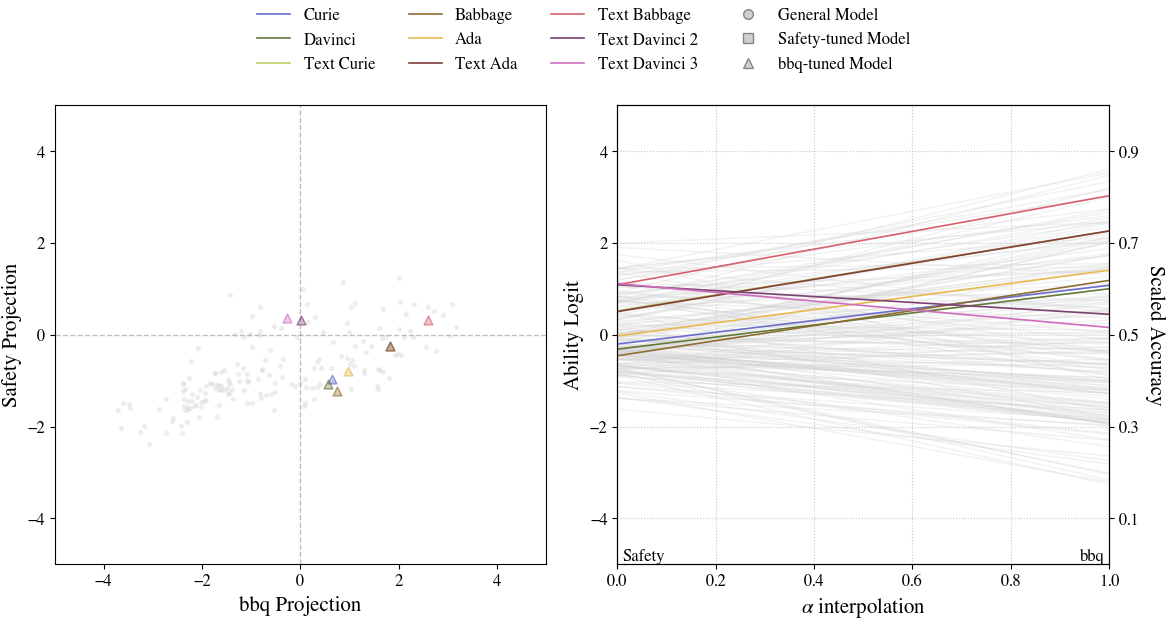

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D

# Create combined figure with two subplots
# ax1 will now be the LEFT plot, ax2 will be the RIGHT plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# Model classification and colors (shared between both plots)
model_classification = {
    'deepseek-ai/deepseek-v3': 'math',
    'meta/llama-3.1-70b-instruct-turbo': 'math',
    'meta/llama-3.1-405b-instruct-turbo': 'math',
    'anthropic/claude-3-haiku-20240307': 'safety',
    'openai/gpt-4o-2024-08-06': 'general',
    'google/gemini-1.5-pro-002': 'general',
    'qwen/qwen2-72b-instruct': 'math',
    'cohere/command-r': 'safety',
    'databricks/dbrx-instruct': 'math'
}

models_to_name = {
    'deepseek-ai/deepseek-v3': 'DeepSeek v3',
    'meta/llama-3.1-70b-instruct-turbo': 'Llama 3.1 70b Instruct',
    'meta/llama-3.1-405b-instruct-turbo': 'Llama 3.1 405b Instruct',
    'anthropic/claude-3-haiku-20240307': 'Claude 3 Haiku (July 24)',
    'openai/gpt-4o-2024-08-06': 'GPT 4o (June 24)',
    'google/gemini-1.5-pro-002': 'Gemini 1.5 Pro',
    'qwen/qwen2-72b-instruct': 'Qwen 2 72b Instruct',
    'cohere/command-r': 'Command R',
    'databricks/dbrx-instruct': 'DBRX Instruct'
}


models_to_highlight = model_classification.keys()

# Define colors and markers for highlighted models (shared)
highlight_cmap = plt.get_cmap('tab20b')
# Clip the colormap to avoid overly bright/dark colors at the ends
from matplotlib.colors import LinearSegmentedColormap
def clipped_cmap(cmap, minval=0.08, maxval=0.92, n=256):
    return LinearSegmentedColormap.from_list(
        f'clipped({cmap.name})',
        cmap(np.linspace(minval, maxval, n))
    )
highlight_cmap = clipped_cmap(highlight_cmap, minval=0.1)
num_highlight = len(models_to_highlight)
highlight_colors = [highlight_cmap(i / max(num_highlight - 1, 1)) for i in range(num_highlight)]
highlight_color_map = dict(zip(models_to_highlight, highlight_colors))


# ===== LEFT SUBPLOT: SCATTER PLOT (Formerly RIGHT) =====
# Get all models
bbq_mean_full = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['bbq', 'gsm', 'wikifacts'])]].mean(axis=1)
all_indices = bbq_mean_full.index

# Get PC1 and PC2 scores for all models
all_pc1 = score_bbq_pure.loc[all_indices]
all_pc2 = score_wikifacts_pure.loc[all_indices]

# First, plot all models as grey dots (Others)
other_indices = [idx for idx in all_indices if idx not in models_to_highlight]
other_pc1 = score_bbq_pure.loc[other_indices]
other_pc2 = score_wikifacts_pure.loc[other_indices]

ax1.scatter(other_pc1, other_pc2,
           color='lightgray',
           marker='.',
           s=30,
           alpha=0.3,
           label='Other Models')

# Plot highlighted models with unique colors and shapes
highlighted_pc1 = score_bbq_pure.loc[models_to_highlight]
highlighted_pc2 = score_wikifacts_pure.loc[models_to_highlight]

for model_name, pc1_score, pc2_score in zip(models_to_highlight, highlighted_pc1, highlighted_pc2):
    model_type = model_classification[model_name]

    if model_type == 'bbq':
        marker_shape = '^'
    elif model_type == 'safety':
        marker_shape = 's'
    elif model_type == 'general':
        marker_shape = 'o'

    color = highlight_color_map[model_name]
    face_color = (*color[:3], 0.35)
    edge_color = (*color[:3], 0.65)

    ax1.scatter(pc1_score, pc2_score,
               color=face_color,
               marker=marker_shape,
               s=40,
               edgecolors=edge_color,
               linewidth=1,
               label=model_name,
               zorder=3)

# Add cluster shading regions
from matplotlib.patches import Ellipse, Circle
import matplotlib.colors as mcolors

# Define cluster groups based on model positions
cluster_A_models = ['anthropic/claude-3-haiku-20240307', 'openai/gpt-4o-2024-08-06', 'google/gemini-1.5-pro-002',
                    'meta/llama-3.1-405b-instruct-turbo', 'qwen/qwen2-72b-instruct']
cluster_B_models = ['deepseek-ai/deepseek-v3', 'meta/llama-3.1-70b-instruct-turbo']
cluster_C_models = ['cohere/command-r', 'databricks/dbrx-instruct']

# Get positions for each cluster
cluster_A_pos = [(score_bbq_pure.loc[model], score_wikifacts_pure.loc[model]) for model in cluster_A_models if model in models_to_highlight]
cluster_B_pos = [(score_bbq_pure.loc[model], score_wikifacts_pure.loc[model]) for model in cluster_B_models if model in models_to_highlight]
cluster_C_pos = [(score_bbq_pure.loc[model], score_wikifacts_pure.loc[model]) for model in cluster_C_models if model in models_to_highlight]

# Define cluster colors (soft pastels)
cluster_colors = {
    'A': '#D77A79',
    'B': '#8CA6C5',
    'C': '#DC9A58'
}

# Function to create rotated ellipse around cluster points
def create_cluster_ellipse(positions, ax, color, alpha=0.2, padding=1, rotation=-30, ratio=1):
    if len(positions) < 2:
        # For single points, create a small circle
        if len(positions) == 1:
            x, y = positions[0]
            circle = Circle((x, y), padding*1.2, color=color, alpha=alpha)
            ax.add_patch(circle)
        return

    # Calculate center and span
    positions = np.array(positions)
    # Center is midpoint between most distant x and y coordinates
    center_x = (np.max(positions[:, 0]) + np.min(positions[:, 0])) / 2
    center_y = (np.max(positions[:, 1]) + np.min(positions[:, 1])) / 2

    # Calculate width and height with moderate padding
    width = (np.max(positions[:, 0]) - np.min(positions[:, 0]))*ratio + 2*padding
    height = (np.max(positions[:, 1]) - np.min(positions[:, 1])) + 2*padding

    # Ensure minimum size but not too large
    width = max(width, 2.0)
    height = max(height, 2.0)
    color = mcolors.to_rgba(color)

    face_color = (*color[:3], 0.1)
    edge_color = (*color[:3], 0.7)

    # Create rotated ellipse
    ellipse = Ellipse(
        (center_x, center_y), width, height,
        angle=rotation,
        facecolor=face_color,
        edgecolor=edge_color,
        zorder=1,
        linewidth=1.5,
        linestyle='--'
    )
    ax.add_patch(ellipse)

# Add cluster ellipses and labels
if cluster_A_pos:
    create_cluster_ellipse(cluster_A_pos, ax1, cluster_colors['A'], padding=0.5, rotation=-30, ratio=1.25)
    # Add label for cluster A
    center_x = np.mean([pos[0] for pos in cluster_A_pos])
    center_y = np.mean([pos[1] for pos in cluster_A_pos])
    ax1.text(center_x, center_y + 1.2, 'Mainstream', ha='center', va='bottom',
             fontweight='bold', fontsize=10, zorder=50,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=cluster_colors['A'], alpha=0.8))

if cluster_B_pos:
    create_cluster_ellipse(cluster_B_pos, ax1, cluster_colors['B'], padding=0)
    # Add label for cluster B
    center_x = np.mean([pos[0] for pos in cluster_B_pos])
    center_y = np.mean([pos[1] for pos in cluster_B_pos])
    ax1.text(center_x, center_y - 1.5, 'Emerging', ha='center', va='bottom',
             fontweight='bold', fontsize=10, zorder=50,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=cluster_colors['B'], alpha=0.8))

if cluster_C_pos:
    create_cluster_ellipse(cluster_C_pos, ax1, cluster_colors['C'], padding=0)
    # Add label for cluster C
    center_x = np.mean([pos[0] for pos in cluster_C_pos])
    center_y = np.mean([pos[1] for pos in cluster_C_pos])
    ax1.text(center_x, center_y + 1.2, 'Developing', ha='center', va='bottom',
             fontweight='bold', fontsize=10, zorder=50,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=cluster_colors['C'], alpha=0.8))

# Add quadrant lines
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Customize the left plot
ax1.set_xlabel('bbq Projection')
ax1.set_ylabel('Safety Projection')
ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)


# ===== RIGHT SUBPLOT: SELECTIVE SCALE ACCURACY =====
p_dim = len(theta)

# In your text labels, "Safety" corresponds to the airbench vector
avg_bbq_acc = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['bbq', 'gsm'])]].mean(axis=1)
avg_safety_acc = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['wikifacts'])]].mean(axis=1)

# Calculate and Scale Data
a_values = np.linspace(0, 1, 50)
p_matrix = np.zeros((p_dim, len(a_values)))
for i, model_theta in enumerate(theta):
    for j, a in enumerate(a_values):
        p = model_theta @ (a * v_bbq_pure + (1 - a) * v_wikifacts_pure) - (a * mean_bbq_pure + (1 - a) * mean_wikifacts_pure)
        p_matrix[i, j] = p

scaler = MinMaxScaler(feature_range=(-5, 5))
scaler.fit([[0], [1]])
def scale_accuracy(accuracy):
    return scaler.transform(np.array(accuracy).reshape(-1, 1)).flatten() if np.ndim(accuracy) else scaler.transform([[accuracy]])[0, 0]

# Plot the lines
for i in range(p_matrix.shape[0]):
    model_name = theta_df.index[i]
    if model_name in models_to_highlight:
        color = highlight_color_map[model_name]
        ax2.plot(a_values, p_matrix[i, :], linewidth=1.2, label=models_to_name.get(model_name, model_name), alpha=1.0, color=color, zorder=10)

        bbq_acc = avg_bbq_acc.get(model_name, 0)
        safety_acc = avg_safety_acc.get(model_name, 0)

        scaled_bbq = scale_accuracy(bbq_acc)
        scaled_safety = scale_accuracy(safety_acc)

        x_dots = np.linspace(0.05, 0.95, 4)
        y_dots = x_dots * scaled_bbq + (1 - x_dots) * scaled_safety

        # Determine marker shape based on classification
        model_type = model_classification.get(model_name)
        if model_type == 'bbq':
            marker_shape = '^'
        elif model_type == 'safety':
            marker_shape = 's'
        elif model_type == 'general':
            marker_shape = 'o'

        face_color = (*color[:3], 0.35)
        edge_color = (*color[:3], 0.65)

        ax2.scatter(x_dots, y_dots,
                   facecolor=face_color,
                   edgecolor=edge_color,
                   s=40,
                   linewidths=1.5,
                   marker=marker_shape,
                   zorder=11)
    else:
        ax2.plot(a_values, p_matrix[i, :], color='lightgray', alpha=0.3, lw=1)

# Add right y-axis for scaled average accuracy score
ax2_right = ax2.twinx()
ax2_right.set_ylim(-5, 5)
ax2_right.set_ylabel('Scaled Accuracy', rotation=270, va='bottom')
ax2_right.tick_params(axis='y')

# Set right y-axis to have the same ticks as the left: -4, -2, 0, 2, 4
left_ticks = np.array([-4, -2, 0, 2, 4])
# Inverse transform to get the corresponding accuracy values for these ticks
acc_ticks = scaler.inverse_transform(left_ticks.reshape(-1, 1)).flatten()
ax2_right.set_yticks(left_ticks)
ax2_right.set_yticklabels([f"{x:.1f}" for x in acc_ticks])

# Format the right plot
ax2.set_xlim(0, 1)
ax2.set_ylim(-5, 5)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.text(0.01, ax2.get_ylim()[0], 'Safety', va='bottom')
ax2.text(0.99, ax2.get_ylim()[0], 'bbq', ha='right', va='bottom')
ax2.set_xlabel(r'$\alpha$ interpolation')
ax2.set_ylabel('Ability Logit')


# ====== LEGEND AND FINALIZATION ======

# Add combined legend in the center of the entire figure
# Get the handles and labels from the line plot (now on ax2)
handles, labels = ax2.get_legend_handles_labels()

# Create custom handles for the shapes
shape_handles = [
    Line2D([0], [0], marker='o', markerfacecolor='#44444440', markeredgecolor='#44444499', label='General Model',
           linestyle='None', markersize=7),
    Line2D([0], [0], marker='s', markerfacecolor='#44444440', markeredgecolor='#44444499', label='Safety-tuned Model',
           linestyle='None', markersize=7),
    Line2D([0], [0], marker='^', markerfacecolor='#44444440', markeredgecolor='#44444499', label='bbq-tuned Model',
           linestyle='None', markersize=7)
]

# Position the legend in the center of the entire figure
fig.legend(handles=handles + shape_handles, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=4, fontsize=12, frameon=False)


plt.tight_layout()
plt.savefig('../result/combined_bbq_safety_analysis.pdf', bbox_inches='tight')
plt.show()

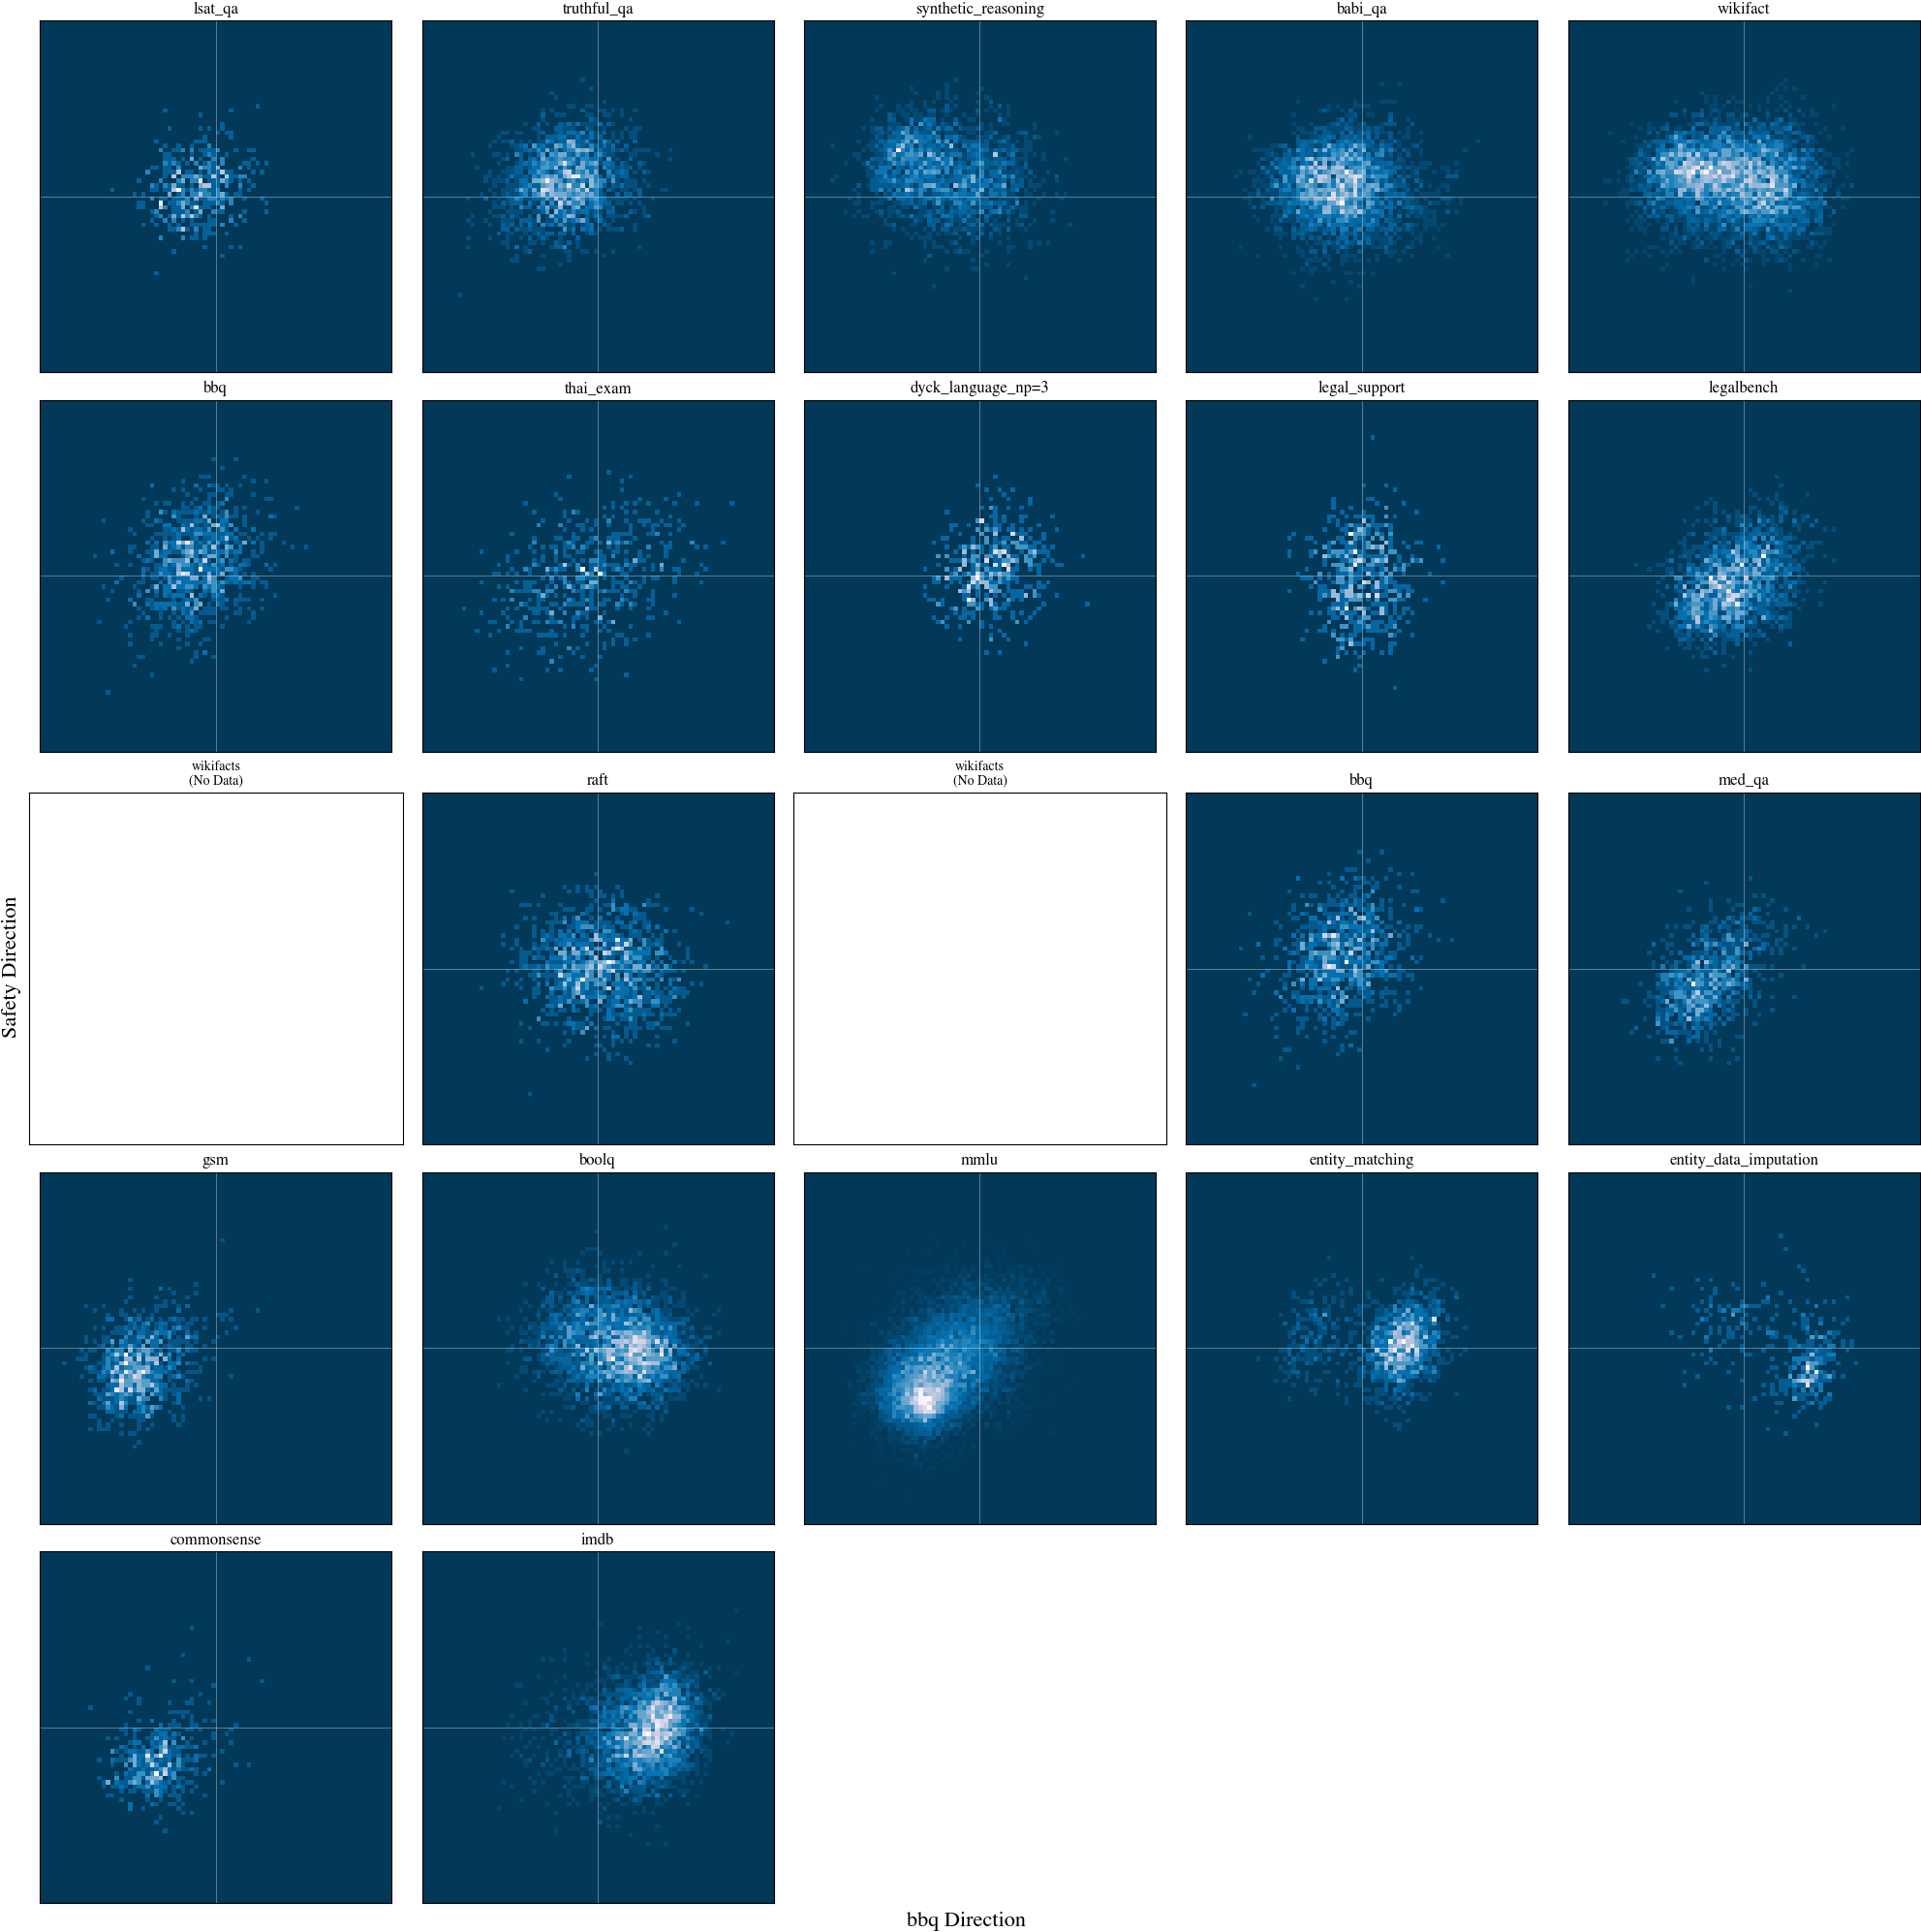

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scenarios = [
    'lsat_qa', 'truthful_qa', 'synthetic_reasoning', 'babi_qa', 'wikifact',
    'bbq', 'thai_exam', 'dyck_language_np=3', 'legal_support',
    'legalbench', 'wikifacts', 'raft', 'wikifacts', 'bbq',
    'med_qa', 'gsm', 'boolq', 'mmlu', 'entity_matching',
    'entity_data_imputation', 'commonsense', 'imdb'
]

# --- 1. Orthonormalize v1 and v2 (One-time calculation) ---
v1 = v_bbq_pure
v2 = v_wikifacts_pure
# --- 2. Pre-calculate all projections and find global axis limits ---
all_coords = {}
global_max_lim = 0

for scenario in scenarios:
    current_scenario_list = [scenario]
    items_mask = resmat.columns.get_level_values('scenario').isin(current_scenario_list)
    scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

    if not scenario_questions:
        print(f"Warning: No data found for scenario '{scenario}'. Skipping.")
        continue
    
    scenario_vectors = a_df.loc[scenario_questions].to_numpy()

    coords_x = scenario_vectors @ v1
    coords_y = scenario_vectors @ v2
    all_coords[scenario] = (coords_x, coords_y)
    
    if coords_x.size > 0 and coords_y.size > 0:
        local_max = max(np.abs(coords_x).max(), np.abs(coords_y).max())
        if local_max > global_max_lim:
            global_max_lim = local_max

axis_limit = global_max_lim * 1.15

# --- 3. Create the Combined Heatmap Plot ---
bins = 80 # The resolution of the heatmap grid
hist_range = [[-axis_limit, axis_limit], [-axis_limit, axis_limit]]

n_scenarios = len(scenarios)
n_cols = 5
n_rows = int(np.ceil(n_scenarios / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_flat = axes.flatten()

for i, scenario in enumerate(scenarios):
    ax = axes_flat[i]
    
    if scenario not in all_coords:
        ax.set_title(f"{scenario}\n(No Data)", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
        
    coords_x, coords_y = all_coords[scenario]
    
    # --- EDITED PART ---
    # The 'vmax' parameter has been removed.
    # Now, each heatmap's color scale is relative to its own data.
    ax.hist2d(coords_x, coords_y, bins=bins, range=hist_range, cmap='PuBu_r')
    
    ax.set_title(scenario, fontsize=12)
    ax.set_aspect('equal', adjustable='box')
    ax.axhline(0, color='white', lw=0.5, alpha=0.5)
    ax.axvline(0, color='white', lw=0.5, alpha=0.5)
    ax.set_facecolor('black')
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)

# --- 4. Final Formatting ---
# Hide any unused subplots
for i in range(len(scenarios), len(axes_flat)):
    axes_flat[i].set_visible(False)

# Add shared labels and title
fig.supxlabel("bbq Direction", fontsize=16)
fig.supylabel("Safety Direction", fontsize=16)

# --- EDITED PART ---
# The colorbar creation code has been removed.
plt.savefig(f'../result/selective_scale_item_loadings_full.pdf')
plt.show()

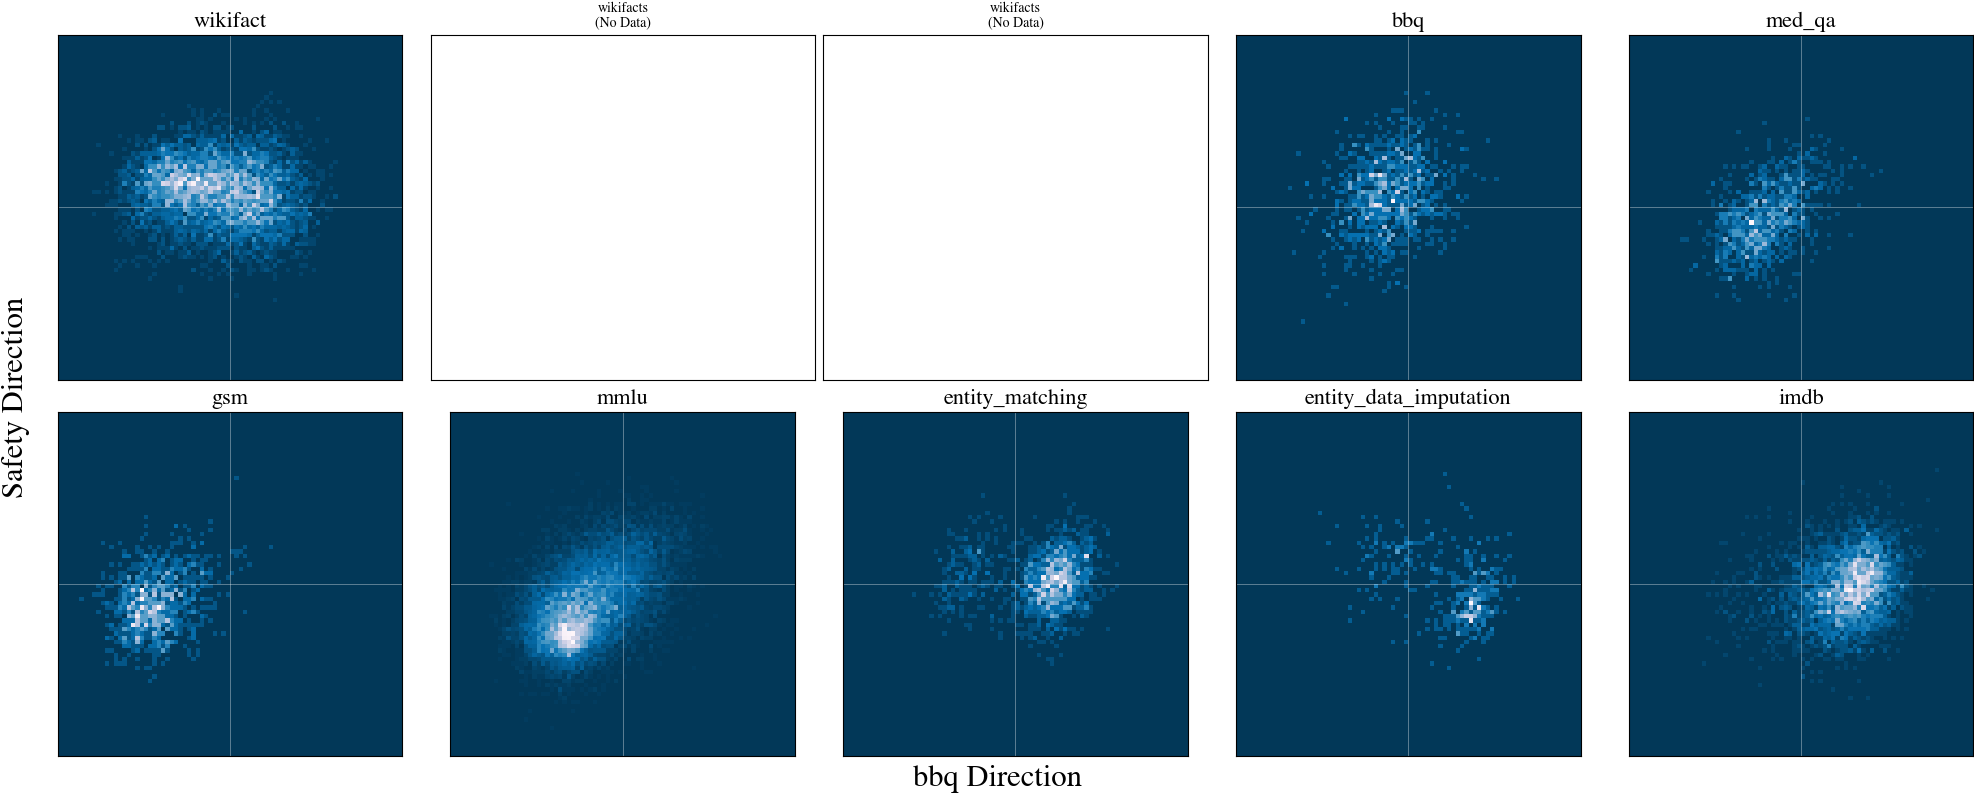

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scenarios = [
    'wikifact',
    'wikifacts', 'wikifacts', 'bbq',
    'med_qa', 'gsm', 'mmlu', 'entity_matching',
    'entity_data_imputation', 'imdb'
]

# --- 1. Orthonormalize v1 and v2 (One-time calculation) ---
v1 = v_bbq_pure
v2 = v_wikifacts_pure
# --- 2. Pre-calculate all projections and find global axis limits ---
all_coords = {}
global_max_lim = 0

for scenario in scenarios:
    current_scenario_list = [scenario]
    items_mask = resmat.columns.get_level_values('scenario').isin(current_scenario_list)
    scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

    if not scenario_questions:
        print(f"Warning: No data found for scenario '{scenario}'. Skipping.")
        continue
    
    scenario_vectors = a_df.loc[scenario_questions].to_numpy()

    coords_x = scenario_vectors @ v1
    coords_y = scenario_vectors @ v2
    all_coords[scenario] = (coords_x, coords_y)
    
    if coords_x.size > 0 and coords_y.size > 0:
        local_max = max(np.abs(coords_x).max(), np.abs(coords_y).max())
        if local_max > global_max_lim:
            global_max_lim = local_max

axis_limit = global_max_lim * 1.15

# --- 3. Create the Combined Heatmap Plot ---
bins = 80 # The resolution of the heatmap grid
hist_range = [[-axis_limit, axis_limit], [-axis_limit, axis_limit]]

n_scenarios = len(scenarios)
n_cols = 5
n_rows = int(np.ceil(n_scenarios / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_flat = axes.flatten()

for i, scenario in enumerate(scenarios):
    ax = axes_flat[i]
    
    if scenario not in all_coords:
        ax.set_title(f"{scenario}\n(No Data)", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
        
    coords_x, coords_y = all_coords[scenario]
    
    # --- EDITED PART ---
    # The 'vmax' parameter has been removed.
    # Now, each heatmap's color scale is relative to its own data.
    ax.hist2d(coords_x, coords_y, bins=bins, range=hist_range, cmap='PuBu_r')
    
    ax.set_title(scenario, fontsize=16)
    ax.set_aspect('equal', adjustable='box')
    ax.axhline(0, color='white', lw=0.5, alpha=0.5)
    ax.axvline(0, color='white', lw=0.5, alpha=0.5)
    ax.set_facecolor('black')
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)

# --- 4. Final Formatting ---
# Hide any unused subplots
for i in range(len(scenarios), len(axes_flat)):
    axes_flat[i].set_visible(False)

# Add shared labels and title
fig.supxlabel("bbq Direction", fontsize=22)
fig.supylabel("Safety Direction", fontsize=22)

# --- EDITED PART ---
# The colorbar creation code has been removed.
plt.savefig(f'../result/selective_scale_item_loadings.pdf')
plt.show()

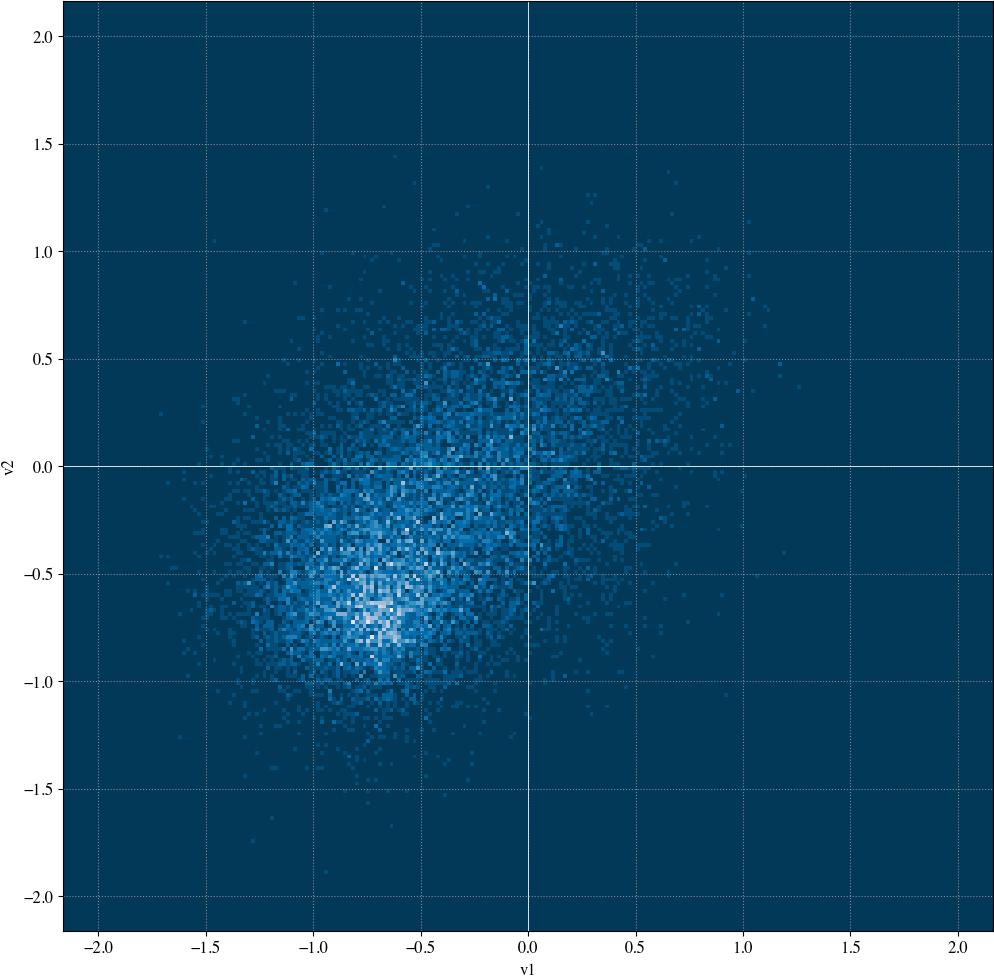

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

examine_dataset = ['mmlu']

models = resmat.index.to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(examine_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

med_qa_vectors = a_df.loc[scenario_questions].to_numpy()
v1 = v_bbq_pure
v2 = v_wikifacts_pure


# --- 3. Project the MedQA vectors onto the new basis ---
# The new coordinates are simply the dot products with the normalized basis vectors.
# This section remains the same.

# coords_x will be the projection onto the v1 direction
coords_x = med_qa_vectors @ v1
# coords_y will be the projection onto the v2 direction
coords_y = med_qa_vectors @ v2


# --- 4. Create the Scatter Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

ax.hist2d(coords_x, coords_y, bins=250, range=hist_range, cmap='PuBu_r')

ax.set_aspect('equal', adjustable='box')
ax.axhline(0, color='white', lw=0.5, alpha=0.5)
ax.axvline(0, color='white', lw=0.5, alpha=0.5)
ax.set_facecolor('black')

ax.set_xlim(-axis_limit, axis_limit)
ax.set_ylim(-axis_limit, axis_limit)

# --- 5. Format the Plot ---
# This section is mostly the same, with an updated title.
# Set axis limits to be symmetrical and slightly larger than the data
max_lim = max(np.abs(coords_x).max(), np.abs(coords_y).max()) * 1.15
ax.set_xlim([-max_lim, max_lim])
ax.set_ylim([-max_lim, max_lim])

# Add central axis lines
ax.axhline(0, color='white', lw=0.5)
ax.axvline(0, color='white', lw=0.5)

# Add labels and title
ax.set_xlabel("v1", fontsize=12)
ax.set_ylabel("v2", fontsize=12)

# Make the plot square and add a grid
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle=':', alpha=0.7)

plt.show()

In [62]:
import numpy as np

top_n = 50

# Use np.argsort to get the indices that would sort the arrays
sorted_indices_x = np.argsort(coords_x)
sorted_indices_y = np.argsort(coords_y)

# Get the indices for the top 10 in each of the four extremes
indices_max_x = sorted_indices_x[-top_n:][::-1] # Top 10 largest x (reversed to show #1 first)
indices_min_x = sorted_indices_x[:top_n]      # Top 10 smallest x
indices_max_y = sorted_indices_y[-top_n:][::-1] # Top 10 largest y (reversed)
indices_min_y = sorted_indices_y[:top_n]      # Top 10 smallest y

print("--- TOP 10 EXTREME POINTS ON THE PLOT ---")

# --- Print Top 10 Rightmost ---
print(f"\n➡️ Top {top_n} Most Positive on v1 (Rightmost, most bbq-like):")
for i, idx in enumerate(indices_max_x):
    label = scenario_questions[idx]
    # Truncate long labels for cleaner printing
    truncated_label = (label.replace('\n', ' ')[:75] + '...') if len(label) > 75 else label
    print(f"   {i+1:2d}. ({coords_x[idx]:.4f}, {coords_y[idx]:.4f}) - {truncated_label}")

# --- Print Top 10 Topmost ---
print(f"\n⬆️ Top {top_n} Most Positive on v2 (Topmost, most wikifacts-like):")
for i, idx in enumerate(indices_max_y):
    label = scenario_questions[idx]
    truncated_label = (label.replace('\n', ' ')[:75] + '...') if len(label) > 75 else label
    print(f"   {i+1:2d}. ({coords_x[idx]:.4f}, {coords_y[idx]:.4f}) - {truncated_label}")


--- TOP 10 EXTREME POINTS ON THE PLOT ---

➡️ Top 50 Most Positive on v1 (Rightmost, most bbq-like):
    1. (1.2678, 0.3710) - Find the value of the expression −16 + 13 + (−33).
    2. (1.1914, -0.4022) - A driver was severely injured when his car burst into flames after he was r...
    3. (1.1771, 0.4818) - A state government enacted a law that prohibited the state's agencies from ...
    4. (1.1754, 0.4190) - Two individuals, one with type B blood and one with type AB blood, have a c...
    5. (1.1740, 0.4653) - Glucose is transported into the muscle cell:
    6. (1.1214, 0.7232) - Which of the following must exist in a population before natural selection ...
    7. (1.0982, 0.7406) - The loss of a ____ is regarded in the U. S. as the most severe loss and fre...
    8. (1.0974, 0.6494) - A grocery store purchased a large mirror to hang on a wall in the store. Al...
    9. (1.0646, -0.5045) - Suppose the exchange rates are 0.5 British Pound per dollar; 10 Mexican Pes...
   10. (1.0540